In [1]:
import numpy as np
import math
# Add the missing attribute back manually
if not hasattr(np, "product"):
    np.product = np.prod
np.math = math
import matplotlib.pyplot as plt
import scipy.constants as cs
import time

import rydcalc

%load_ext memory_profiler

## Saving and Reusing the Dipole Matrix Element Cache

### Pre-computing the Entire Cache

In [2]:
# define lowest energy states that will be searched over
Yb171 = rydcalc.Ytterbium171(cpp_numerov=True,use_db=False)
st_yb = Yb171.get_state((78,0,1/2,-1/2))

Rb = rydcalc.Rubidium87(cpp_numerov=True,use_db=False)
st_rb = Rb.get_state((58,0,1/2,-1/2))

# see https://iopscience.iop.org/article/10.1088/0031-8949/91/10/104007/pdf for recommended values
opts_rb = {'dn': 3,'dl': 2,'dm': 2,'dipole_allowed': False} #{'dn': 6,'dl': 8,'dm': 20,'dipole_allowed': False}
opts_yb = {'dn': 2,'dl': 2,'dm': 20,'dipole_allowed': False} #{'dn': 3,'dl': 6,'dm': 20,'dipole_allowed': False}

# define the number of states to center single state bases around
# for each of these states, the pairstate basis is constructed to consider ~2000 different single atom states
num_center_states = 50

rb_basis = rydcalc.single_basis()
rb_basis.fill(st_rb, include_opts=opts_rb)
print(len(rb_basis.states))

yb_basis = rydcalc.single_basis()
yb_basis.fill(st_yb, include_opts=opts_yb)
print(len(yb_basis.states))


100
374


In [ ]:
mes_yb = rydcalc.precompute_multipole_me(Yb171, [78,0,1/2,-1/2], opts_rb, 5)

In [ ]:
mes_rb = rydcalc.precompute_multipole_me(Rb, [58,0,1/2,-1/2], opts_rb, 5)

We want to access all calculated dipole matrix elements directly in a hash table in memory to speed up access time. This should be viable on the cluster with a table size on the order of 10 GB, and lookups will be faster than accessing them from a database using the built in (though not fully implemented) db_manager.

In [ ]:
# try saving and reloading the computed matrix elements
rydcalc.save_mes_json('rb_matrix_elements.json', mes_rb)
rydcalc.save_mes_json('yb_matrix_elements.json', mes_yb)

del mes_rb
del mes_yb

mes_rb = rydcalc.load_mes_json('rb_matrix_elements.json')
mes_yb = rydcalc.load_mes_json('yb_matrix_elements.json')

print(len(mes_rb))
print(len(mes_yb))

In [ ]:
opts_pair = {'dn': 2,'dl': 2,'dm': 20,'dipole_allowed': False, 'pair_include_fn': lambda p,p0: np.abs(p0.energy_Hz-p.energy_Hz)<3e9}

start_time = time.perf_counter()
pair_int = rydcalc.analysis_pair_interaction(st_yb, st_rb,include_opts = opts_pair, a1_precomputed_me=mes_yb, a2_precomputed_me=mes_rb)
end_time = time.perf_counter()

print('Done computing matrix elements, basis size=', pair_int.pb.dim(), ', after elapsed time ', (end_time-start_time))


We are getting a lot of cache misses because of poor overlap between the individual `single_basis` objects used to pre-compute the matrix elements and the `pair_basis` object used by analysis. Rather than sink more time into figuring this out, I'm taking the lazy approach and using a pre-existing caching library that will cache only the matrix elements we use in calculating the Hamiltonian.

### Dynamically Populating the Cache

2124
computing the hamiltonians
computed diagonal elements in 0.0015041670000073282 s
computed HEz and Hint in 20.444796750000023 s
computed HBdiam in 29.301460458999998 s
Done calculating hamiltonians, basis size= 2124 , after elapsed time  42.067602459
performing analysis
Done performing analysis, basis size= 2124 , after elapsed time  0.0011836249999817028


100%|██████████| 34/34 [00:18<00:00,  1.87it/s]


peak memory: 2585.62 MiB, increment: 1686.69 MiB


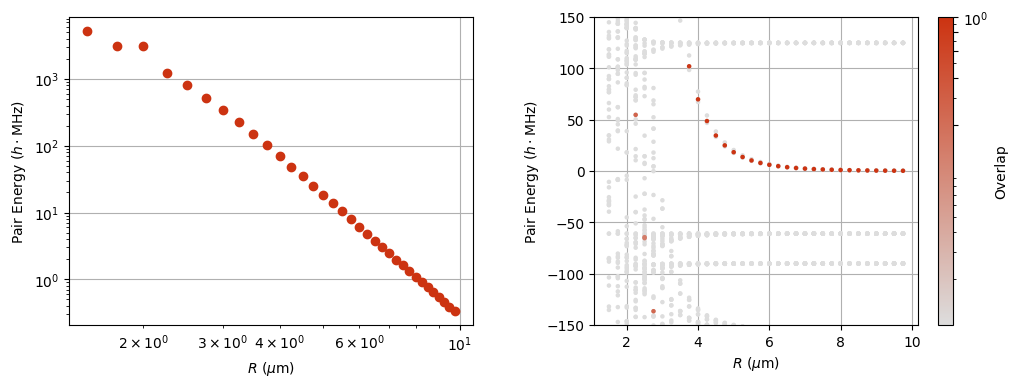

In [ ]:
%%memit
# define lowest energy states that will be searched over
Yb171 = rydcalc.Ytterbium171(cpp_numerov=True,use_db=False)
st_yb = Yb171.get_state((63.11,0,1/2,1/2))

Rb = rydcalc.Rubidium87(cpp_numerov=True,use_db=False)
st_rb = Rb.get_state((66,0,1/2,1/2))

opts_pair = {'dn': 2,'dl': 3,'dm': 3,'dipole_allowed': False, 'pair_include_fn': lambda p,p0: np.abs(p0.energy_Hz-p.energy_Hz)<2e9}

# generate the pair_basis_pre_computation object that will be used by analysis script with caching
pb = rydcalc.pair_basis_pre_computation()
pb.fill(rydcalc.pair(st_yb, st_rb), include_opts=opts_pair)

print(pb.dim())

print('computing the hamiltonians')
start_time = time.perf_counter()
pb.computeHamiltonians(multipoles=[[1,1]])
end_time = time.perf_counter()
print('Done calculating hamiltonians, basis size=', pb.dim(), ', after elapsed time ', (end_time-start_time))

print('performing analysis')
start_time = time.perf_counter()
pair_int = rydcalc.analysis_pair_interaction(st_yb, st_rb, pb=pb, include_opts = opts_pair)
end_time = time.perf_counter()
print('Done performing analysis, basis size=', pair_int.pb.dim(), ', after elapsed time ', (end_time-start_time))

rList_um = np.arange(1.5,10,0.25)
pair_int.run(rList_um=rList_um, th=0*np.pi/2)
fig,axs = pair_int.pa_plot(include_plot_opts={'ov_norm': 'log', 'log_norm': [0.01,1]})
axs[1].set_ylim([-150,150])


Basis size: 2124
Done computing matrix elements, basis size= 2124 , after elapsed time  120.399556083


100%|██████████| 34/34 [23:29<00:00, 41.47s/it]  


peak memory: 2265.81 MiB, increment: 2102.52 MiB


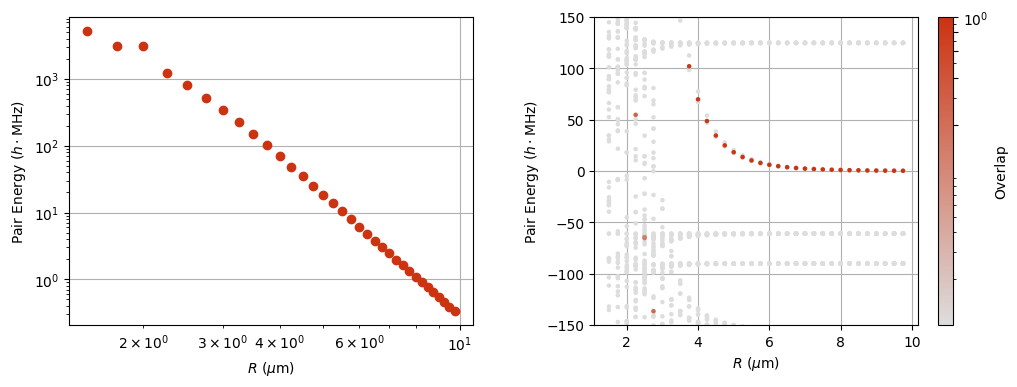

In [4]:
%%memit
# compare to non-optimized performance
start_time = time.perf_counter()
pair_int = rydcalc.analysis_pair_interaction(st_yb, st_rb,include_opts = opts_pair)
end_time = time.perf_counter()

print('Done computing matrix elements, basis size=', pair_int.pb.dim(), ', after elapsed time ', (end_time-start_time))

rList_um = np.arange(1.5,10,0.25)
pair_int.run(rList_um=rList_um, th=0*np.pi/2)
fig,axs = pair_int.pa_plot(include_plot_opts={'ov_norm': 'log', 'log_norm': [0.01,1]})
axs[1].set_ylim([-150,150])

In [5]:
import sys

def real_array_memory(pb):
    total = 0

    for name in ["HEz", "HBz", "HBdiam", "H0"]:
        arr = getattr(pb, name, None)
        if arr is not None:
            total += arr.nbytes

    for arr in getattr(pb, "HInt", []):
        total += arr.nbytes

    for pair in pb.pairs:
        total += sys.getsizeof(pair)

    return total / (1024**2)

print(real_array_memory(pb), "MB")

309.86883544921875 MB


### Multiprocessing

The above code computes the components of the Hamiltonian in parallel, but matrix elements are not parallelized

# Benchmarking

1. Convergence tests at a range of states and field values
    - interspecies and intraspecies (singlet and triplet states of Yb)

In [20]:
Bz = 10
rList_um = np.arange(2, 10, 0.2)

# this function repeatedly runs an analysis_pair_interaction with larger pairstate bases
# until the absolute relative delta between the interaction coefficients on subsequent runs goes
# below delta_threshold
def update_opts_to_convergence(s1, s2, init_opts, delta_threshold=1e-5):
    # INPUTS:
    # - s1 and s2 are the rydberg states of atom 1 and atom 2
    # - init_opts are the initial pairstate basis options
    # - delta_threshold is min total relative in interaction coefs before returning
    # RETURNS:
    # - opts: the pairstate basis options that satisfy the convergence test

    delta = 1e10
    prev = None
    opts = init_opts

    while delta > delta_threshold:
        pb = rydcalc.pair_basis_pre_computation()
        pb.fill(rydcalc.pair(s1, s2), include_opts=opts)
        print(opts)
        print(f'generated next pairstate basis with dimension {pb.dim()}')
        pb.computeHamiltonians(multipoles=[[1,1]])

        pair_int = rydcalc.analysis_pair_interaction(s1, s2, include_opts=opts)
        result = pair_int.run(rList_um=rList_um, th=0, Bz_Gauss=Bz)

        if not(prev is None):
            deltas = [np.abs((prev[i]-result[i]) / (result[i]+1e-10)) for i in range(len(result))]
            print(deltas)
            delta = sum(deltas)
            print(f'current delta: {delta}')

        prev = result

        # for now increase n but not l
        opts['dn'] += 1

    return opts


### Interspecies Tests
- all tests performed at **Bz=10 Gauss**

**Test 1:** $n_{Yb}=63.11,\ n_{Rb}=66$, Yb in singlet state

In [22]:
st_yb = Yb171.get_state((63,0,1/2,1/2))
st_rb = Rb.get_state((66,0,1/2,1/2))

init_opts = {'dn': 1,'dl': 2,'dm': 2,'dipole_allowed': False, 'pair_include_fn': lambda p,p0: np.abs(p0.energy_Hz-p.energy_Hz)<2e9}

opts = update_opts_to_convergence(st_yb, st_rb, init_opts)

print(f'final pairstate options: {opts}')

{'dn': 1, 'dl': 2, 'dm': 2, 'dipole_allowed': False, 'pair_include_fn': <function <lambda> at 0x127104790>}
generated next pairstate basis with dimension 474
computed diagonal elements in 5.400000009103678e-05 s
computed HEz and Hint in 0.5783081660001699 s
computed HBz in 1.300784499999736 s
computed HBdiam in 1.3339668339999662 s
Basis size: 474


100%|██████████| 40/40 [00:00<00:00, 85.22it/s]


{'dn': 2, 'dl': 2, 'dm': 2, 'dipole_allowed': False, 'pair_include_fn': <function <lambda> at 0x127104790>}
generated next pairstate basis with dimension 730
computed diagonal elements in 8.095800012597465e-05 s
computed HEz and Hint in 1.6083312079999814 s
computed HBdiam in 2.737195000000156 s
computed HBz in 7.194112666999899 s
Basis size: 730


100%|██████████| 40/40 [00:01<00:00, 32.23it/s]


[np.float64(1.1682520313871299), np.float64(0.0), np.float64(0.8233467817007237), np.float64(0.0)]
current delta: 1.9915988130878537
{'dn': 3, 'dl': 2, 'dm': 2, 'dipole_allowed': False, 'pair_include_fn': <function <lambda> at 0x127104790>}
generated next pairstate basis with dimension 1234
computed diagonal elements in 0.0005982500001664448 s
computed HEz and Hint in 5.414573291999659 s
computed HBdiam in 7.1451818330001515 s
computed HBz in 24.258758124999986 s
Basis size: 1234


100%|██████████| 40/40 [00:04<00:00,  8.88it/s]


[np.float64(4.921538378178767e-06), np.float64(0.0), np.float64(6.974611662911112e-06), np.float64(0.0)]
current delta: 1.189615004108988e-05
{'dn': 4, 'dl': 2, 'dm': 2, 'dipole_allowed': False, 'pair_include_fn': <function <lambda> at 0x127104790>}
generated next pairstate basis with dimension 1615
computed diagonal elements in 0.0010170419996029523 s
computed HEz and Hint in 8.567287832999682 s
computed HBdiam in 11.890913917000034 s
Basis size: 1615


100%|██████████| 40/40 [00:08<00:00,  4.46it/s]


[np.float64(3.874478240005534e-06), np.float64(0.0), np.float64(1.5980661116847099e-06), np.float64(0.0)]
current delta: 5.472544351690244e-06
final pairstate options: {'dn': 5, 'dl': 2, 'dm': 2, 'dipole_allowed': False, 'pair_include_fn': <function <lambda> at 0x127104790>}


**Test 2:** $n_{Yb}=73,\ n_{Rb}=76$, Yb in singlet state

In [23]:
st_yb = Yb171.get_state((73,0,1/2,1/2))
st_rb = Rb.get_state((76,0,1/2,1/2))

init_opts = {'dn': 1,'dl': 2,'dm': 2,'dipole_allowed': False, 'pair_include_fn': lambda p,p0: np.abs(p0.energy_Hz-p.energy_Hz)<2e9}

opts = update_opts_to_convergence(st_yb, st_rb, init_opts)

print(f'final pairstate options: {opts}')

{'dn': 1, 'dl': 2, 'dm': 2, 'dipole_allowed': False, 'pair_include_fn': <function <lambda> at 0x127154670>}
generated next pairstate basis with dimension 546
computed diagonal elements in 7.479100031559938e-05 s
computed HBz in 4.438957584000036 s
computed HBdiam in 7.143467041999884 s
computed HEz and Hint in 7.5628673750002235 s
Basis size: 546


100%|██████████| 40/40 [00:00<00:00, 62.49it/s]


{'dn': 2, 'dl': 2, 'dm': 2, 'dipole_allowed': False, 'pair_include_fn': <function <lambda> at 0x127154670>}
generated next pairstate basis with dimension 1334
computed diagonal elements in 0.0002314580001439026 s
computed HBz in 15.733804499999678 s
computed HBdiam in 16.97176912499981 s
computed HEz and Hint in 23.3453770000001 s
Basis size: 1334


100%|██████████| 40/40 [00:05<00:00,  7.52it/s]


[np.float64(0.3209131257259336), np.float64(0.0), np.float64(0.3500897293401501), np.float64(0.0)]
current delta: 0.6710028550660837
{'dn': 3, 'dl': 2, 'dm': 2, 'dipole_allowed': False, 'pair_include_fn': <function <lambda> at 0x127154670>}
generated next pairstate basis with dimension 2049
computed diagonal elements in 0.0014145000000098662 s
computed HBdiam in 30.599205583000185 s
computed HBz in 37.31507408300013 s
computed HEz and Hint in 45.898555290999866 s
Basis size: 2049


...

[np.float64(1.7287348073377664), np.float64(0.0), np.float64(4.561687066637797), np.float64(0.0)]
current delta: 6.290421873975563
{'dn': 4, 'dl': 2, 'dm': 2, 'dipole_allowed': False, 'pair_include_fn': <function <lambda> at 0x127154670>}
generated next pairstate basis with dimension 2500
computed diagonal elements in 0.001803707999897597 s
computed HBdiam in 37.87468287499996 s
computed HEz and Hint in 51.01848729100038 s
Basis size: 2500


100%|██████████| 40/40 [00:37<00:00,  1.08it/s]


[np.float64(0.0005625128734415493), np.float64(0.0), np.float64(0.0006044181336171116), np.float64(0.0)]
current delta: 0.001166931007058661
{'dn': 5, 'dl': 2, 'dm': 2, 'dipole_allowed': False, 'pair_include_fn': <function <lambda> at 0x127154670>}
generated next pairstate basis with dimension 2864
computed diagonal elements in 0.002189291999911802 s
computed HBdiam in 43.71586529200022 s
computed HEz and Hint in 54.4346879159998 s
Basis size: 2864


100%|██████████| 40/40 [01:00<00:00,  1.51s/it]


[np.float64(4.3180448134796393e-07), np.float64(0.0), np.float64(1.0485323772596709e-06), np.float64(0.0)]
current delta: 1.4803368586076349e-06
final pairstate options: {'dn': 6, 'dl': 2, 'dm': 2, 'dipole_allowed': False, 'pair_include_fn': <function <lambda> at 0x127154670>}


**Test 3:** $n_{Yb}=83,\ n_{Rb}=86$, Yb in singlet state

In [ ]:
%%memit

st_yb = Yb171.get_state((83,0,1/2,1/2))
st_rb = Rb.get_state((86,0,1/2,1/2))

init_opts = {'dn': 1,'dl': 2,'dm': 2,'dipole_allowed': False, 'pair_include_fn': lambda p,p0: np.abs(p0.energy_Hz-p.energy_Hz)<2e9}

opts = update_opts_to_convergence(st_yb, st_rb, init_opts)

print(f'final pairstate options: {opts}')

{'dn': 1, 'dl': 2, 'dm': 2, 'dipole_allowed': False, 'pair_include_fn': <function <lambda> at 0x15751bd30>}
generated next pairstate basis with dimension 1090
computed diagonal elements in 0.0005306250004650792 s
computed HBz in 1.6569670409990067 s
computed HEz and Hint in 5.082703042000503 s
computed HBdiam in 6.683294917000239 s
Basis size: 1090


100%|██████████| 40/40 [00:03<00:00, 12.20it/s]


{'dn': 2, 'dl': 2, 'dm': 2, 'dipole_allowed': False, 'pair_include_fn': <function <lambda> at 0x15751bd30>}
generated next pairstate basis with dimension 2177
computed diagonal elements in 0.006192500000906875 s
computed HBz in 8.26984049999919 s
computed HEz and Hint in 20.94100866699955 s
computed HBdiam in 23.006903625000632 s
Basis size: 2177


KeyboardInterrupt: 

**Test 4:** $n_{Yb}=63,\ n_{Rb}=66$, Yb in triplet state

In [ ]:
st_yb = Yb171.get_state((63,0,3/2,1/2))
st_rb = Rb.get_state((66,0,1/2,1/2))

init_opts = {'dn': 1,'dl': 2,'dm': 2,'dipole_allowed': False, 'pair_include_fn': lambda p,p0: np.abs(p0.energy_Hz-p.energy_Hz)<2e9}

opts = update_opts_to_convergence(st_yb, st_rb, init_opts)

print(f'final pairstate options: {opts}')

**Test 5:** $n_{Yb}=73,\ n_{Rb}=76$, Yb in triplet state

In [ ]:
st_yb = Yb171.get_state((73,0,3/2,1/2))
st_rb = Rb.get_state((76,0,1/2,1/2))

init_opts = {'dn': 1,'dl': 2,'dm': 2,'dipole_allowed': False, 'pair_include_fn': lambda p,p0: np.abs(p0.energy_Hz-p.energy_Hz)<2e9}

opts = update_opts_to_convergence(st_yb, st_rb, init_opts)

print(f'final pairstate options: {opts}')

**Test 6:** $n_{Yb}=83,\ n_{Rb}=86$, Yb in triplet state

In [ ]:
st_yb = Yb171.get_state((83,0,3/2,1/2))
st_rb = Rb.get_state((86,0,1/2,1/2))

init_opts = {'dn': 1,'dl': 2,'dm': 2,'dipole_allowed': False, 'pair_include_fn': lambda p,p0: np.abs(p0.energy_Hz-p.energy_Hz)<2e9}

opts = update_opts_to_convergence(st_yb, st_rb, init_opts)

print(f'final pairstate options: {opts}')

### Intraspecies Yb-Yb Tests
- all tests performed at **Bz=10 Gauss**

**Test 1:** $n_{Yb}=63$, Yb in singlet state

In [ ]:
st_yb = Yb171.get_state((63,0,1/2,1/2))

init_opts = {'dn': 1,'dl': 2,'dm': 2,'dipole_allowed': False, 'pair_include_fn': lambda p,p0: np.abs(p0.energy_Hz-p.energy_Hz)<2e9}

opts = update_opts_to_convergence(st_yb, st_yb, init_opts)

print(f'final pairstate options: {opts}')

**Test 2:** $n_{Yb}=83$, Yb in singlet state

In [ ]:
st_yb = Yb171.get_state((83,0,1/2,1/2))

init_opts = {'dn': 1,'dl': 2,'dm': 2,'dipole_allowed': False, 'pair_include_fn': lambda p,p0: np.abs(p0.energy_Hz-p.energy_Hz)<2e9}

opts = update_opts_to_convergence(st_yb, st_yb, init_opts)

print(f'final pairstate options: {opts}')

**Test 3:** $n_{Yb}=63$, Yb in triplet state

In [ ]:
st_yb = Yb171.get_state((63,0,3/2,1/2))

init_opts = {'dn': 1,'dl': 2,'dm': 2,'dipole_allowed': False, 'pair_include_fn': lambda p,p0: np.abs(p0.energy_Hz-p.energy_Hz)<2e9}

opts = update_opts_to_convergence(st_yb, st_yb, init_opts)

print(f'final pairstate options: {opts}')

**Test 4:** $n_{Yb}=83$, Yb in triplet state

In [ ]:
st_yb = Yb171.get_state((83,0,3/2,1/2))

init_opts = {'dn': 1,'dl': 2,'dm': 2,'dipole_allowed': False, 'pair_include_fn': lambda p,p0: np.abs(p0.energy_Hz-p.energy_Hz)<2e9}

opts = update_opts_to_convergence(st_yb, st_yb, init_opts)

print(f'final pairstate options: {opts}')

### Intraspecies Rb-Rb Tests
- all tests performed at **Bz=10 Gauss**

**Test 1:** $n_{Rb}=66$

In [ ]:
st_rb = Rb.get_state((66,0,1/2,1/2))

init_opts = {'dn': 1,'dl': 2,'dm': 2,'dipole_allowed': False, 'pair_include_fn': lambda p,p0: np.abs(p0.energy_Hz-p.energy_Hz)<2e9}

opts = update_opts_to_convergence(st_rb, st_rb, init_opts)

print(f'final pairstate options: {opts}')

**Test 2:** $n_{Yb}=76$

In [ ]:
st_rb = Rb.get_state((76,0,1/2,1/2))

init_opts = {'dn': 1,'dl': 2,'dm': 2,'dipole_allowed': False, 'pair_include_fn': lambda p,p0: np.abs(p0.energy_Hz-p.energy_Hz)<2e9}

opts = update_opts_to_convergence(st_rb, st_rb, init_opts)

print(f'final pairstate options: {opts}')

**Test 3:** $n_{Yb}=86$

In [ ]:
st_rb = Rb.get_state((86,0,1/2,1/2))

init_opts = {'dn': 1,'dl': 2,'dm': 2,'dipole_allowed': False, 'pair_include_fn': lambda p,p0: np.abs(p0.energy_Hz-p.energy_Hz)<2e9}

opts = update_opts_to_convergence(st_rb, st_rb, init_opts)

print(f'final pairstate options: {opts}')